Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - loss: 0.8686 
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - loss: 0.3397
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step - loss: 0.1590
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 312us/step - loss: 0.0973
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step - loss: 0.0732
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step - loss: 0.0601
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step - loss: 0.0520
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 313us/step - loss: 0.0462
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - loss: 0.0421
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step - loss: 0.0377
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step
two example output vectors:
 [[3.9959042e-03 9.9738818e-03 9.7240269e-01 1.3627449e-02]
 [9.9888223e-01 1.0931593e-03 7.3477513e-06 1.7254124e-05]]
largest value 0.99999964 smallest value 2.8744642e-08
[-2.1747978  -1.2600976   3.3197026  -0.94798124], category: 2
[ 9.620746   2.8031807

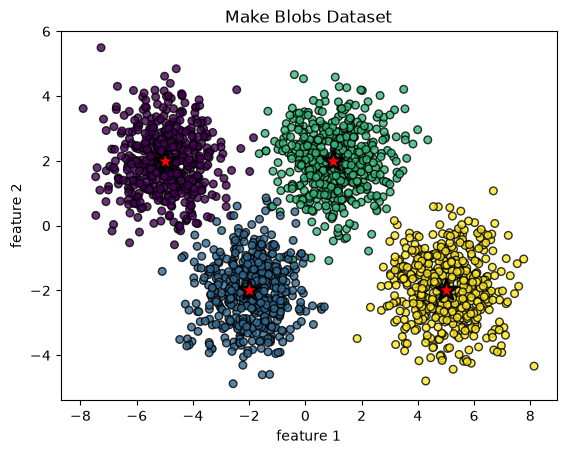

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.src.ops import SparseCategoricalCrossentropy
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
import sklearn
from sklearn.datasets import make_blobs

centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
X_train, y_train = make_blobs(n_samples=2000, centers=centers, cluster_std=1.0,random_state=30)

model = Sequential( [
    Dense(units = 25, activation = 'relu'),
    Dense(units = 15, activation = 'relu'),
    Dense(units = 4, activation = 'linear')
])

model.compile(loss = SparseCategoricalCrossentropy(from_logits = True), optimizer = tf.keras.optimizers.Adam(0.001))

model.fit(X_train, y_train, epochs = 10)

#the model doesn't output probabilties (the better numerical version) so we run it through softmax
p = model.predict(X_train)
sm = tf.nn.softmax(p).numpy()
print(f"two example output vectors:\n {sm[:2]}")
print("largest value", np.max(sm), "smallest value", np.min(sm))

#selecting the most likely category
for i in range(5):
    print( f"{p[i]}, category: {np.argmax(p[i])}")

#plotting the dataset
plt.title("Make Blobs Dataset")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=30, alpha=0.8)
plt.scatter(np.array(centers)[:, 0], np.array(centers)[:, 1], marker='*', color='red', s=250, edgecolor='black', linewidths=2, zorder=10)
plt.show()